In [7]:
import requests
import json
import matplotlib.pyplot as plt

In [8]:
url = "https://raw.githubusercontent.com/wpilibsuite/allwpilib/main/apriltag/src/main/native/resources/edu/wpi/first/apriltag/2026-rebuilt-welded.json"

print(f"Fetching data from {url}...")

response = requests.get(url)
response.raise_for_status() # Check for HTTP errors
data = response.json()

print("Data fetched successfully. Generating plot...")

Fetching data from https://raw.githubusercontent.com/wpilibsuite/allwpilib/main/apriltag/src/main/native/resources/edu/wpi/first/apriltag/2026-rebuilt-welded.json...
Data fetched successfully. Generating plot...


In [9]:
# Extract field dimensions (defaulting to standard sizes if missing, though 2026 JSON should have them)
    # Note: Field dimensions in the JSON are in meters
field_length = data.get('field', {}).get('length', 17.55) 
field_width = data.get('field', {}).get('width', 8.05)

tags = data.get('tags', [])

ids = []
x_coords = []
y_coords = []

In [10]:
# Extract ID and Translation (X, Y) for each tag
for tag in tags:
    tag_id = tag.get('ID')
    # The JSON structure typically has pose -> translation -> x, y, z
    pose = tag.get('pose', {})
    translation = pose.get('translation', {})
    
    x = translation.get('x')
    y = translation.get('y')
    
    if tag_id is not None and x is not None and y is not None:
        ids.append(tag_id)
        x_coords.append(x)
        y_coords.append(y)

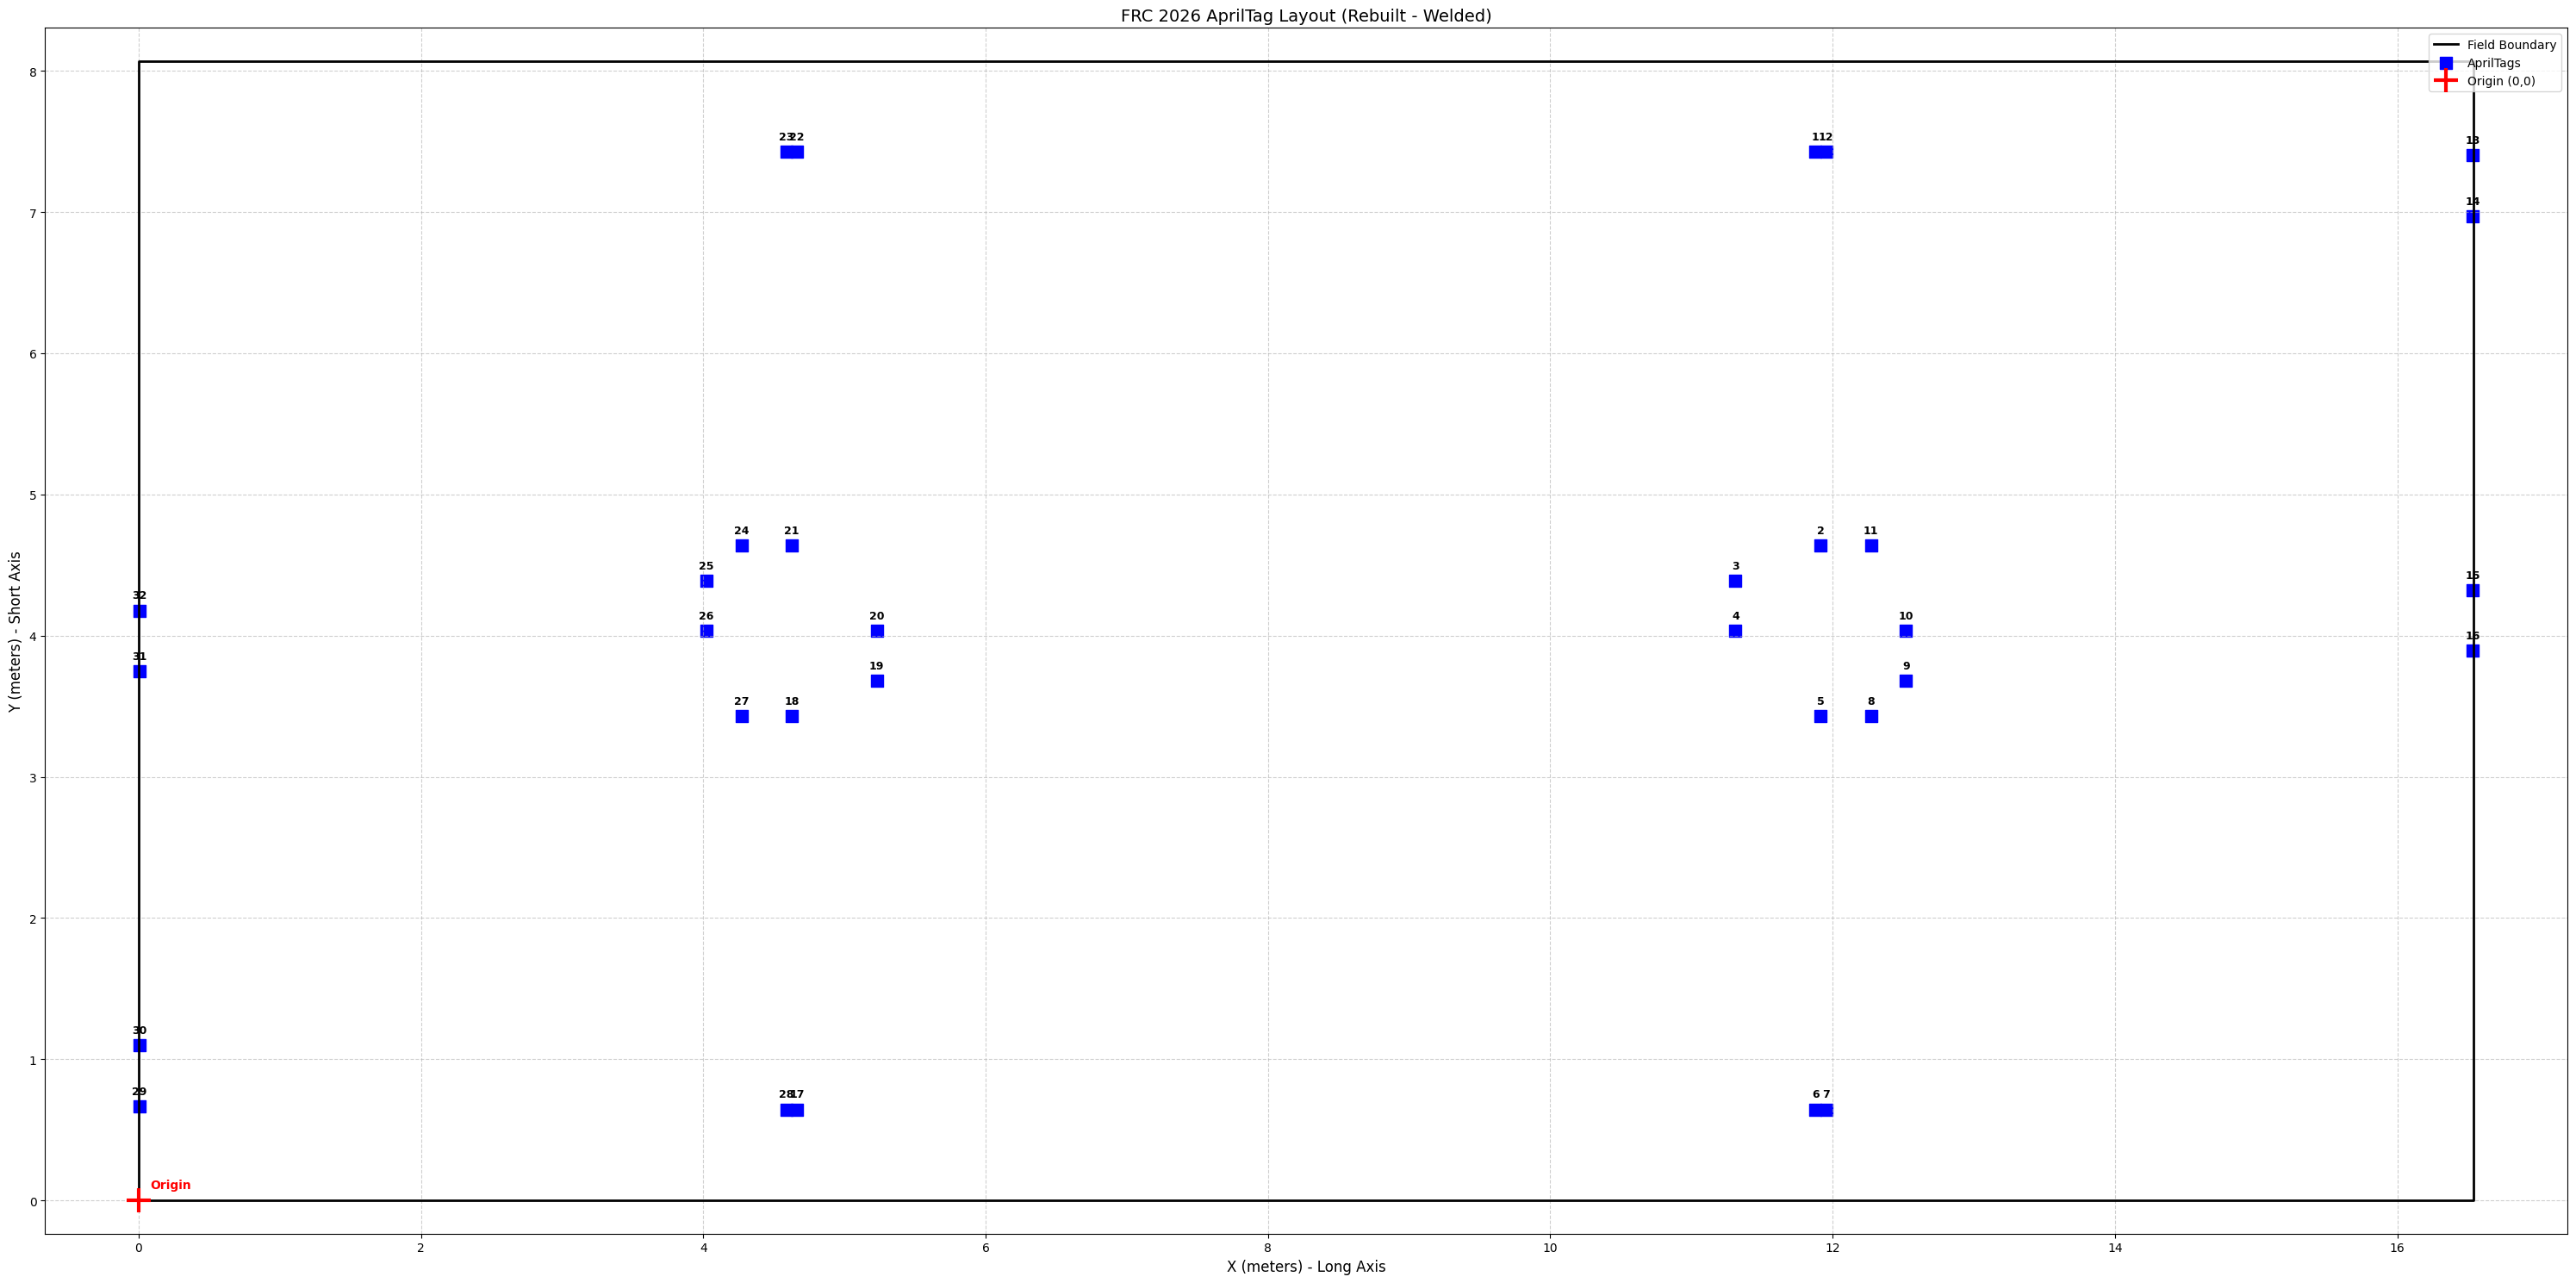

In [13]:
# Setup the plot
plt.figure(figsize=(30, 15))

# Plot the field boundary (approximate based on length/width)
plt.plot([0, field_length, field_length, 0, 0], [0, 0, field_width, field_width, 0], 
            'k-', linewidth=2, label='Field Boundary')

# Plot the AprilTags
plt.scatter(x_coords, y_coords, color='blue', s=100, marker='s', label='AprilTags')

# Label each tag with its ID
for i, tag_id in enumerate(ids):
    plt.annotate(str(tag_id), (x_coords[i], y_coords[i]), 
                    xytext=(0, 8), textcoords='offset points', 
                    ha='center', va='bottom', fontsize=9, weight='bold')

# Mark and Label the Origin (0,0)
# In FRC (Blue Alliance Origin), (0,0) is usually the bottom-right corner of the Blue Alliance wall
plt.plot(0, 0, 'r+', markersize=20, markeredgewidth=3, label='Origin (0,0)')
plt.annotate("Origin", (0, 0), xytext=(10, 10), textcoords='offset points', color='red', weight='bold')

# Formatting
plt.title("FRC 2026 AprilTag Layout (Rebuilt - Welded)", fontsize=14)
plt.xlabel("X (meters) - Long Axis", fontsize=12)
plt.ylabel("Y (meters) - Short Axis", fontsize=12)
plt.axis('equal') # Ensure the aspect ratio represents physical reality
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')

# Show the plot
plt.tight_layout()
plt.show()